In [1]:
#imports:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import numpy as np

In [2]:
#read in undoped film data for 730nm
#p aka power, # for mW
p01 = pd.read_csv(r"I:\projects\spinlab_data\IMF Data\2024-05-17 Empty Film Laser Power Scans\730nm\730p01_2024-05-17-164455.txt", sep="\t")
p1 = pd.read_csv(r"I:\projects\spinlab_data\IMF Data\2024-05-17 Empty Film Laser Power Scans\730nm\730p1_2024-05-17-163134.txt", sep="\t")
p002 = pd.read_csv(r"I:\projects\spinlab_data\IMF Data\2024-05-17 Empty Film Laser Power Scans\730nm\730p002_2024-05-17-165103.txt", sep="\t")
p2 = pd.read_csv(r"I:\projects\spinlab_data\IMF Data\2024-05-17 Empty Film Laser Power Scans\730nm\730p2_2024-05-17-162655.txt", sep="\t")
p05 = pd.read_csv(r"I:\projects\spinlab_data\IMF Data\2024-05-17 Empty Film Laser Power Scans\730nm\730p05_2024-05-17-163553.txt", sep="\t")
p5 = pd.read_csv(r"I:\projects\spinlab_data\IMF Data\2024-05-17 Empty Film Laser Power Scans\730nm\730p5_2024-05-17-162241.txt", sep="\t")
p10 = pd.read_csv(r"I:\projects\spinlab_data\IMF Data\2024-05-17 Empty Film Laser Power Scans\730nm\730p10_2024-05-17-161718.txt", sep="\t")
p025 = pd.read_csv(r"I:\projects\spinlab_data\IMF Data\2024-05-17 Empty Film Laser Power Scans\730nm\730p025_2024-05-17-164030.txt", sep="\t")

In [3]:
#read in undoped settings data for 730nm
#sp aka settings power
sp01 = pd.read_csv(r"I:\projects\spinlab_data\IMF Data\2024-05-17 Empty Film Laser Power Scans\730nm\730p01_2024-05-17-164455_SETTINGS.txt", header=None,sep=":")
sp1 = pd.read_csv(r"I:\projects\spinlab_data\IMF Data\2024-05-17 Empty Film Laser Power Scans\730nm\730p1_2024-05-17-163134_SETTINGS.txt", header=None,sep=":")
sp002 = pd.read_csv(r"I:\projects\spinlab_data\IMF Data\2024-05-17 Empty Film Laser Power Scans\730nm\730p002_2024-05-17-165103_SETTINGS.txt",header=None,sep=":")
sp2 = pd.read_csv(r"I:\projects\spinlab_data\IMF Data\2024-05-17 Empty Film Laser Power Scans\730nm\730p2_2024-05-17-162655_SETTINGS.txt", header=None,sep=":")
sp05 = pd.read_csv(r"I:\projects\spinlab_data\IMF Data\2024-05-17 Empty Film Laser Power Scans\730nm\730p05_2024-05-17-163553_SETTINGS.txt", header=None,sep=":")
sp5 = pd.read_csv(r"I:\projects\spinlab_data\IMF Data\2024-05-17 Empty Film Laser Power Scans\730nm\730p5_2024-05-17-162241_SETTINGS.txt", header=None,sep=":")
sp10 = pd.read_csv(r"I:\projects\spinlab_data\IMF Data\2024-05-17 Empty Film Laser Power Scans\730nm\730p10_2024-05-17-161718_SETTINGS.txt", header=None,sep=":")
sp025 = pd.read_csv(r"I:\projects\spinlab_data\IMF Data\2024-05-17 Empty Film Laser Power Scans\730nm\730p025_2024-05-17-164030_SETTINGS.txt", header=None,sep=":")

In [4]:
#add all undoped files to a list in order of increasing power
undoped_730 = [p002, p01, p025, p05, p1, p2, p5, p10]

#add all settings files to a list in order of increasing power
undoped_settings_730 = [sp002, sp01, sp025, sp05, sp1, sp2, sp5, sp10]

In [5]:
#find average voltage for each undoped file, add them to a new list
averageVoltageUndoped = []
for i in range(len(undoped_730)):
    averageVoltageUndoped.append(undoped_730[i].iloc[:,2].mean())

In [6]:
#convert power meter range (W) to mW
for i in range(len(undoped_settings_730)):
   undoped_settings_730[i].loc[3,1] = undoped_settings_730[i].loc[3,1]*1000
#Erin's code says divide it by 2, not really sure why 
#power = voltage x power range / 2
#convert from V to mW
averagePowerUndoped = []
for i in range(len(undoped_730)):
    averagePowerUndoped.append(averageVoltageUndoped[i] * ((undoped_settings_730[i].loc[3,1])/2))

In [7]:
#find average counts per frame
averageCountsUndoped = []
cpsUndoped = []
for i in range(len(undoped_730)):
    averageCountsUndoped.append((undoped_730[i].iloc[:,4].mean()))

#now counts per second, divide average by exposure time (from settings files)
for i in range(len(averageCountsUndoped)):
    cpsUndoped.append(averageCountsUndoped[i]/undoped_settings_730[i].iloc[1,1])

In [8]:
#now onto doped! 
#read in doped data files
#dp aka doped power
dp01 = pd.read_csv(r"I:\projects\spinlab_data\IMF Data\2024-03-27 Laser Power Scans\730nm\LaserPowerScan_730nm_tenthmW_2024-03-27-175126.txt", sep="\t")
dp1 = pd.read_csv(r"I:\projects\spinlab_data\IMF Data\2024-03-27 Laser Power Scans\730nm\LaserPowerScan_730nm_1mW_2024-03-27-173810.txt", sep="\t")
dp002 = pd.read_csv(r"I:\projects\spinlab_data\IMF Data\2024-03-27 Laser Power Scans\730nm\LaserPowerScan_730nm_2hundredthsmW_2024-03-27-175524.txt", sep="\t")
dp2 = pd.read_csv(r"I:\projects\spinlab_data\IMF Data\2024-03-27 Laser Power Scans\730nm\LaserPowerScan_730nm_2mW_2024-03-27-173333.txt", sep="\t")
dp05 = pd.read_csv(r"I:\projects\spinlab_data\IMF Data\2024-03-27 Laser Power Scans\730nm\LaserPowerScan_730nm_halfmW_2024-03-27-174210.txt", sep="\t")
dp5 = pd.read_csv(r"I:\projects\spinlab_data\IMF Data\2024-03-27 Laser Power Scans\730nm\LaserPowerScan_730nm_5mW_2024-03-27-172941.txt", sep="\t")
dp10 = pd.read_csv(r"I:\projects\spinlab_data\IMF Data\2024-03-27 Laser Power Scans\730nm\LaserPowerScan_730nm_10mW_2024-03-27-172322.txt", sep="\t")
dp025 = pd.read_csv(r"I:\projects\spinlab_data\IMF Data\2024-03-27 Laser Power Scans\730nm\LaserPowerScan_730nm_quartermW_2024-03-27-174656.txt", sep="\t")

In [9]:
#read in doped settings
#sdp aka settings doped power
sdp01 = pd.read_csv(r"I:\projects\spinlab_data\IMF Data\2024-03-27 Laser Power Scans\730nm\LaserPowerScan_730nm_tenthmW_2024-03-27-175126_SETTINGS.txt", header=None,sep=":")
sdp1 = pd.read_csv(r"I:\projects\spinlab_data\IMF Data\2024-03-27 Laser Power Scans\730nm\LaserPowerScan_730nm_1mW_2024-03-27-173810_SETTINGS.txt", header=None,sep=":")
sdp002 = pd.read_csv(r"I:\projects\spinlab_data\IMF Data\2024-03-27 Laser Power Scans\730nm\LaserPowerScan_730nm_2hundredthsmW_2024-03-27-175524_SETTINGS.txt",header=None,sep=":")
sdp2 = pd.read_csv(r"I:\projects\spinlab_data\IMF Data\2024-03-27 Laser Power Scans\730nm\LaserPowerScan_730nm_2mW_2024-03-27-173333_SETTINGS.txt", header=None,sep=":")
sdp05 = pd.read_csv(r"I:\projects\spinlab_data\IMF Data\2024-03-27 Laser Power Scans\730nm\LaserPowerScan_730nm_halfmW_2024-03-27-174210_SETTINGS.txt", header=None,sep=":")
sdp5 = pd.read_csv(r"I:\projects\spinlab_data\IMF Data\2024-03-27 Laser Power Scans\730nm\LaserPowerScan_730nm_5mW_2024-03-27-172941_SETTINGS.txt", header=None,sep=":")
sdp10 = pd.read_csv(r"I:\projects\spinlab_data\IMF Data\2024-03-27 Laser Power Scans\730nm\LaserPowerScan_730nm_10mW_2024-03-27-172322_SETTINGS.txt", header=None,sep=":")
sdp025 = pd.read_csv(r"I:\projects\spinlab_data\IMF Data\2024-03-27 Laser Power Scans\730nm\LaserPowerScan_730nm_quartermW_2024-03-27-174656_SETTINGS.txt", header=None,sep=":")

In [10]:
#make lists for doped
doped_730 = [dp002, dp01, dp025, dp05, dp1, dp2, dp5, dp10]

#add all settings files to a list in order of increasing power
doped_settings_730 = [sdp002, sdp01, sdp025, sdp05, sdp1, sdp2, sdp5, sdp10]

In [11]:
#find average voltage for each doped file
averageVoltageDoped = []
for i in range(len(doped_730)):
    averageVoltageDoped.append(doped_730[i].iloc[:,2].mean())

In [12]:
#convert power meter range (W) to mW
for i in range(len(doped_settings_730)):
   doped_settings_730[i].loc[3,1] = doped_settings_730[i].loc[3,1]*1000
#convert from V to mW
averagePowerDoped = []
for i in range(len(doped_730)):
    averagePowerDoped.append(averageVoltageDoped[i] * ((doped_settings_730[i].loc[3,1])/2))

In [13]:
#find average counts per frame
#cps for counts per second
averageCountsDoped = []
cpsDoped = []
for i in range(len(doped_730)):
    averageCountsDoped.append((doped_730[i].iloc[:,4].mean()))
#now counts per second, divide average by exposure time (from settings files)
for i in range(len(averageCountsDoped)):
    cpsDoped.append(averageCountsDoped[i]/doped_settings_730[i].iloc[1,1])

In [14]:
#now read in bias data (no film)
bias = pd.read_csv(r"I:\projects\spinlab_data\IMF Data\2024-04-11 Bias for Laser Power Scans\Bias_LPS_2024-04-11-105342.txt", sep="\t")
bias_settings = pd.read_csv(r"I:\projects\spinlab_data\IMF Data\2024-04-11 Bias for Laser Power Scans\Bias_LPS_2024-04-11-105342_SETTINGS.txt", header=None, sep=":")
#find average counts
bias_avg_counts = bias.iloc[:,4].mean()
#find counts per second
bias_cps = bias_avg_counts / .00001

In [15]:
#subtract bias from doped and undoped datas
cpsDopedNoBias = []
for i in cpsDoped:
    cpsDopedNoBias.append(i-bias_cps)
cpsUndopedNoBias = []
for i in cpsUndoped:
    cpsUndopedNoBias.append(i-bias_cps)

In [16]:
#rescaling values to make curve_fit work (they're too big!!)
y_scale = 1E10
cpsDopedScaled = np.array(cpsDoped) / y_scale
cpsUndopedScaled = np.array(cpsUndoped) / y_scale
#no bias values
cpsDopedScaledNB = np.array(cpsDopedNoBias) / y_scale
cpsUndopedScaledNB = np.array(cpsUndopedNoBias) / y_scale

In [17]:
#dropping the final 2 points on the doped film since they appear to be at saturation
averagePowerDopedGraph = averagePowerDoped[0:5]
cpsDopedGraph = cpsDopedScaled[0:5]
#no bias version
cpsDopedGraphNB = cpsDopedScaledNB[0:5]

In [18]:
#fit curves
def linear(m,x,b):
    return ( m * x ) + b
x_fit = np.linspace(0,12)
#undoped fitting
best, ignore = curve_fit(linear, averagePowerUndoped, cpsUndopedScaled)
slope_undoped = best[0]
offset_undoped = best[1]
fit_undoped = linear(x_fit, slope_undoped, offset_undoped)
#doped fitting
best2, ignore = curve_fit(linear, averagePowerDopedGraph, cpsDopedGraph)
slope_doped = best2[0]
offset_doped = best2[1]
fit_doped = linear(x_fit, slope_doped, offset_doped)
#vs no bias versions
#undoped fitting
best3, ignore = curve_fit(linear, averagePowerUndoped, cpsUndopedScaledNB)
slope_undopedNB = best3[0]
offset_undopedNB = best3[1]
fit_undopedNB = linear(x_fit, slope_undopedNB, offset_undopedNB)
#doped fitting
best4, ignore = curve_fit(linear, averagePowerDopedGraph, cpsDopedGraphNB)
slope_dopedNB = best4[0]
offset_dopedNB = best4[1]
fit_dopedNB = linear(x_fit, slope_dopedNB, offset_dopedNB)

In [19]:
#rescale
fit_undoped = fit_undoped * y_scale
fit_doped = fit_doped * y_scale
#no bias rescaling
fit_undopedNB = fit_undopedNB * y_scale
fit_dopedNB = fit_dopedNB * y_scale

In [20]:
#find the difference btwn doped and undoped
#with bias
difference = np.array(fit_doped) - np.array(fit_undoped)
#without bias
differenceNB = fit_dopedNB - fit_undopedNB
#Assuming bias is constant across the graph, make a list of bias y values to graph (to match length of x_fit)
bias_graphing = []
for i in range(0,50):
    bias_graphing.append(bias_cps)

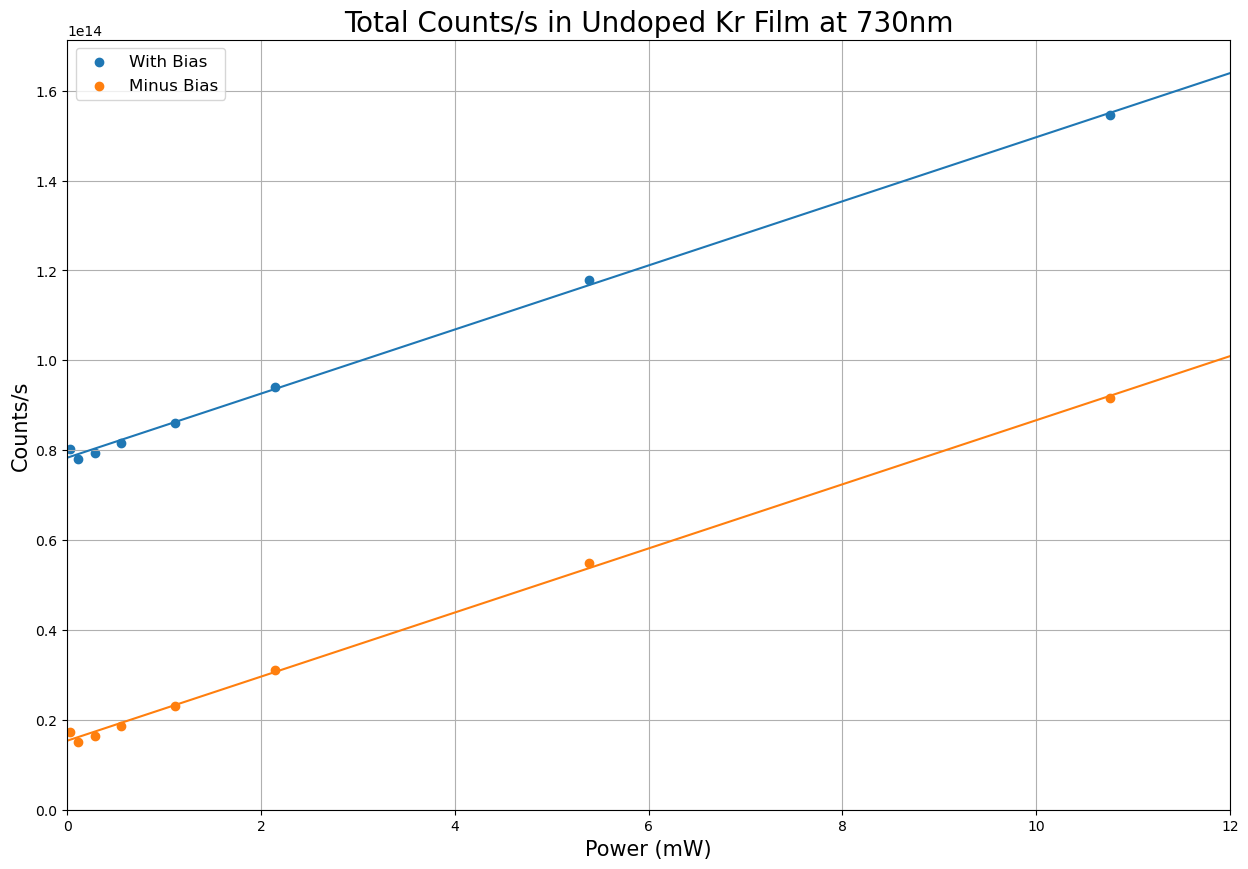

y = 1.54e+13 x + 1.71e+13


In [26]:
#plotting undoped
plt.figure(figsize=(15,10))
#with bias
plt.scatter(averagePowerUndoped, np.array(cpsUndoped), label="With Bias")
plt.plot(x_fit, fit_undoped)
#without bias
plt.scatter(averagePowerUndoped, cpsUndopedNoBias, label="Minus Bias")
plt.plot(x_fit, fit_undopedNB)
plt.xlabel("Power (mW)", fontsize=15)
plt.ylabel("Counts/s", fontsize=15)
plt.grid()
plt.title("Total Counts/s in Undoped Kr Film at 730nm", fontsize=20)
plt.xlim(0,12)
plt.ylim(0)
plt.legend(fontsize=12)
plt.show()
print("y =", "{:.2e}".format(fit_undopedNB[0]), "x +", "{:.2e}".format(fit_undopedNB[1]))

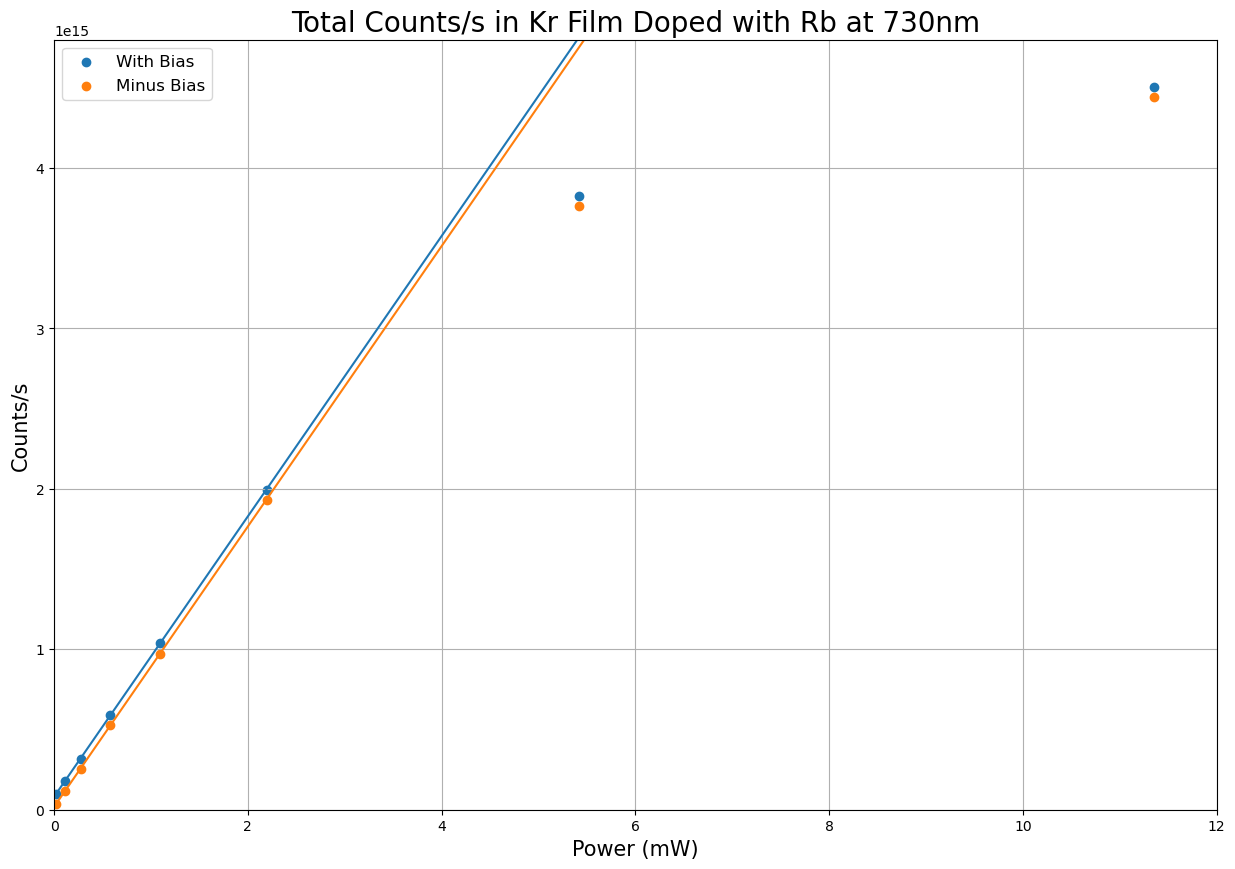

y = 1.87e+13 x + 2.33e+14
3.76e+15


In [29]:
#plotting doped
plt.figure(figsize=(15,10))
plt.title("Total Counts/s in Kr Film Doped with Rb at 730nm", fontsize=20)
plt.xlabel("Power (mW)", fontsize=15)
plt.ylabel("Counts/s", fontsize=15)
plt.grid()
#with bias
plt.scatter(averagePowerDoped, cpsDoped, label="With Bias")
plt.plot(x_fit, fit_doped)
#without bias
plt.scatter(averagePowerDoped, cpsDopedNoBias, label="Minus Bias")
plt.plot(x_fit, fit_dopedNB)
plt.xlim(0,12)
plt.ylim(0,4.8E15)
plt.legend(fontsize=12)
plt.show()
print("y =", "{:.2e}".format(fit_dopedNB[0]), "x +", "{:.2e}".format(fit_dopedNB[1]))
print("{:.2e}".format(cpsDopedNoBias[6]))

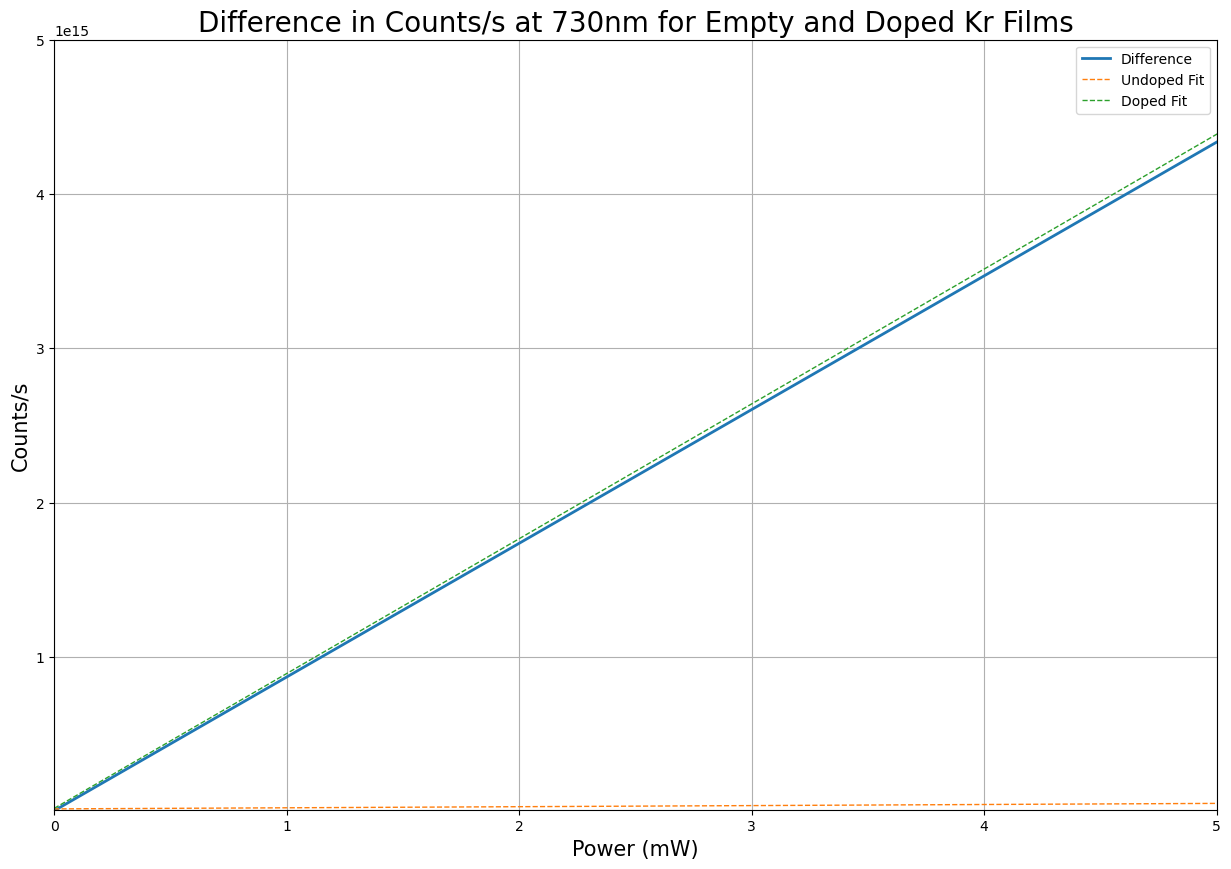

y = 3.29e+12 x + 2.16e+14


In [30]:
#plt.plot(x_fit, (difference - bias_cps))
plt.figure(figsize=(15,10))
plt.plot(x_fit, differenceNB, label='Difference', linewidth=2)
plt.title("Difference in Counts/s at 730nm for Empty and Doped Kr Films", fontsize=20)
plt.xlabel("Power (mW)",fontsize=15)
plt.ylabel("Counts/s",fontsize=15)
plt.xlim(0,5)
plt.ylim(1E13,.5E16)
plt.grid()
plt.plot(x_fit, fit_undopedNB,linewidth=1,linestyle='--',label='Undoped Fit')
plt.plot(x_fit, fit_dopedNB, linewidth=1,linestyle='--', label='Doped Fit')
plt.legend()
plt.show()
print("y =","{:.2e}".format(differenceNB[0]),"x +", "{:.2e}".format(differenceNB[1]))